In [20]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extraction Complete!")

Extraction Complete!


In [21]:
import os

os.listdir('/content/dataset')



['cards', 'tarot-images.json']

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

from PIL import Image



In [23]:
with open("/content/dataset/tarot-images.json", "r") as f:
    tarot_data = json.load(f)

type(tarot_data)


dict

In [24]:
tarot_data.keys()


dict_keys(['description', 'cards'])

In [25]:
df = pd.DataFrame(tarot_data["cards"])

In [26]:
df.head()

,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]","{'light': ['Freeing yourself from limitation',...",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]","{'light': ['Taking appropriate action', 'Recei...",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",{'light': ['Listening to your feelings and int...,The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]","{'light': ['Nurturing yourself and others', 'B...",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]","{'light': ['Exercising authority', 'Defining l...",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,NaN,NaN


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   meanings            78 non-null     object
 8   Archetype           22 non-null     object
 9   Hebrew Alphabet     22 non-null     object
 10  Numerology          62 non-null     object
 11  Elemental           38 non-null     object
 12  Mythical/Spiritual  22 non-null     object
 13  Questions to Ask    78 non-null     object
 14  Astrology           40 non-null     object
 15  Affirmation         56 non-null     object
dtypes: object(16)
memory usage: 

In [28]:
import json

with open('/content/dataset/tarot-images.json', 'r') as file:
    data = json.load(file)

print(data)

{'description': 'tarot cards and basic information about them, as well as references to corresponding scans', 'cards': [{'name': 'The Fool', 'number': '0', 'arcana': 'Major Arcana', 'suit': 'Trump', 'img': 'm00.jpg', 'fortune_telling': ['Watch for new projects and new beginnings', 'Prepare to take something on faith', 'Something new comes your way; go for it'], 'keywords': ['freedom', 'faith', 'inexperience', 'innocence'], 'meanings': {'light': ['Freeing yourself from limitation', 'Expressing joy and youthful vigor', 'Being open-minded', 'Taking a leap of faith', 'Attuning yourself to your instincts', 'Being eager or curious', 'Exploring your potential', 'Embracing innovation and change'], 'shadow': ['Being gullible and naive', 'Taking unnecessary risks', 'Failing to be serious when required', 'Being silly or distracted', 'Lacking experience', 'Failing to honor well-established traditions and limits', 'Behaving inappropriately']}, 'Archetype': 'The Divine Madman', 'Hebrew Alphabet': 'A

In [29]:
df[["name", "number", "arcana", "suit", "img"]].duplicated().sum()

np.int64(0)

In [30]:
df["arcana"].value_counts()

,count
arcana,
Minor Arcana,56
Major Arcana,22


In [31]:
df["suit"].value_counts()

,count
suit,
Trump,22
Cups,14
Swords,14
Wands,14
Pentacles,14


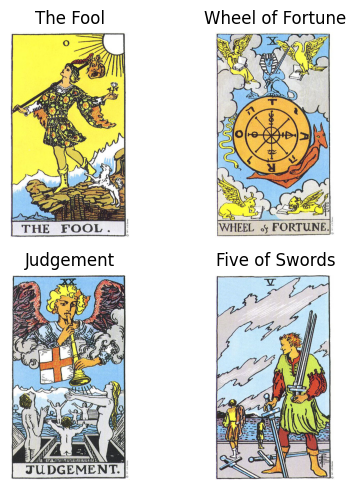

In [32]:
sample_cards = df.iloc[[0, 10, 20, 40]]

plt.figure(figsize=(5,5))

for i, (_, row) in enumerate(sample_cards.iterrows()):
    img = Image.open(f"/content/dataset/cards/{row['img']}")

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(row["name"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
img = Image.open("/content/dataset/cards/" + df.iloc[0]["img"])

print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (350, 600)
Image Mode: RGB


In [34]:
from PIL import Image
import os

sizes = []

image_folder = "/content/dataset/cards/"

for img_name in df["img"]:
    img_path = os.path.join(image_folder, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

unique_sizes = set(sizes)

print("Number of unique image sizes:", len(unique_sizes))
print("Different sizes:", unique_sizes)

Number of unique image sizes: 1
Different sizes: {(350, 600)}


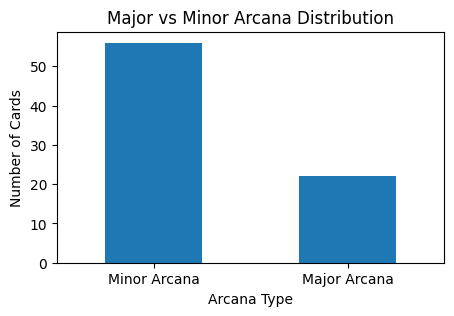

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

df["arcana"].value_counts().plot(kind="bar")

plt.title("Major vs Minor Arcana Distribution")
plt.xlabel("Arcana Type")
plt.ylabel("Number of Cards")
plt.xticks(rotation=0)

plt.show()


Key Insights

- The dataset contains a total of 78 Tarot cards, consisting of 22 Major Arcana cards and 56 Minor Arcana cards.

- Trump Suit (Major Arcana): There are 22 cards categorized as "Trump", which represent the Major Arcana cards.

- Minor Arcana Suits: The four standard suits each have a perfectly balanced count of 14 cards.

- The images have a consistent resolution of 350 × 600 pixels.

- All images are stored in RGB format with pixel values ranging from 0 to 255, making them suitable for deep learning-based image processing.

- The output values are stored as 64-bit integers (dtype: int64).